# Libreta de Pruebas Para Generacion de Rutas usando OSM
### Demostracion y ejemplos de genracion de las rutas

## Extraccion de Datos de la Zona

c:\Users\malco\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


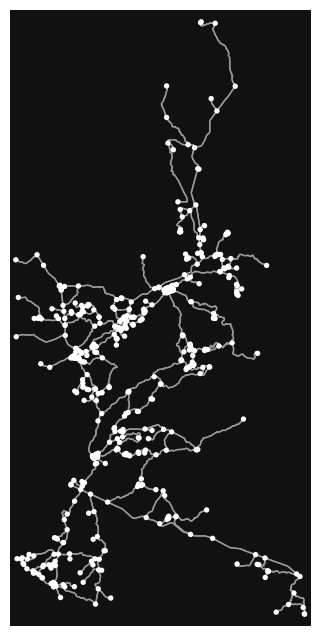

In [1]:
import json
import osmnx as ox
from shapely.geometry import shape

# Paso 1: Leer archivo GeoJSON
with open("VillaPesqueira.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Paso 2: Extraer geometría del primer feature (el polígono)
polygon = shape(data["features"][0]["geometry"])

# Paso 3: Descargar red vial dentro del polígono
G = ox.graph_from_polygon(polygon, network_type="drive")

# Paso 4: Visualizar o guardar
ox.plot_graph(G)  # Mostrar grafo
ox.save_graphml(G, "villa_pesqueira.graphml")  # Guardar para usar después


## Generacion de una ruta

Ruta: [(29.0609327, -110.0609359), (29.0612276, -110.0603517), (29.0615129, -110.0595106), (29.0616308, -110.0588451), (29.0615657, -110.0579157), (29.0611859, -110.0570977), (29.0608115, -110.0545152), (29.0643258, -110.0515053), (29.0645315, -110.0510238), (29.0657916, -110.0468825), (29.0686694, -110.0400763), (29.0700056, -110.0370663), (29.0801915, -110.0197463), (29.0846935, -110.0165829), (29.0860204, -110.0159725), (29.0925187, -110.0088602), (29.0959674, -110.0074283), (29.1010306, -110.0054129), (29.1015737, -110.0051731), (29.1076064, -110.0033019), (29.118824, -109.9806722), (29.1198561, -109.9772188), (29.1196587, -109.9764068), (29.1183518, -109.9710014), (29.1180659, -109.9701874), (29.1181479, -109.9694806), (29.1180382, -109.969098), (29.1181468, -109.9688248), (29.1182229, -109.9683447), (29.1182511, -109.9681301), (29.1183044, -109.9673966), (29.1183319, -109.9667139)]


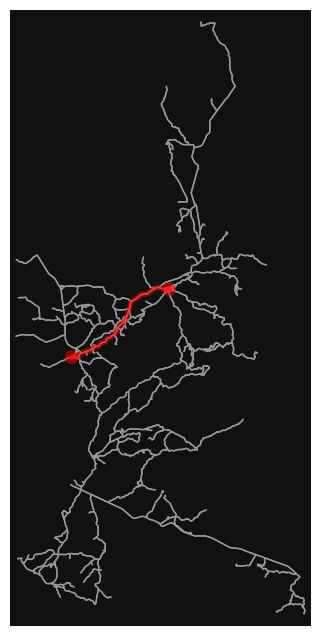

In [5]:
import networkx as nx
# Cargar el archivo GeoJSON
with open("VillaPesqueira.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Crear el polígono a partir del GeoJSON
polygon = shape(data["features"][0]["geometry"])

# Crear el grafo vial de la zona
G = ox.graph_from_polygon(polygon, network_type="drive")

# ---------------------------
# Seleccionar origen y destino (puedes cambiar estos valores)
# ---------------------------
origen_lat, origen_lon = 29.060924, -110.060873  # cerca del centro de Villa Pesqueira
destino_lat, destino_lon = 29.118444, -109.966675 # punto arbitrario al este

# Obtener los nodos más cercanos
origen_nodo = ox.distance.nearest_nodes(G, origen_lon, origen_lat)
destino_nodo = ox.distance.nearest_nodes(G, destino_lon, destino_lat)

# Calcular la ruta más corta con A*
ruta_nodos = nx.astar_path(G, origen_nodo, destino_nodo, weight="length")

# Obtener las coordenadas (lat/lon) de la ruta
ruta_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in ruta_nodos]

# Mostrar en consola
print("Ruta:", ruta_coords)

# Mostrar en gráfico
fig, ax = ox.plot_graph_route(G, ruta_nodos, route_linewidth=4, node_size=0)

## Generacion de Rutas Con Indicaciones y Distancia

Ruta: [(29.0609327, -110.0609359), (29.0612276, -110.0603517), (29.0615129, -110.0595106), (29.0616308, -110.0588451), (29.0615657, -110.0579157), (29.0611859, -110.0570977), (29.0608115, -110.0545152), (29.0643258, -110.0515053), (29.0645315, -110.0510238), (29.0657916, -110.0468825), (29.0686694, -110.0400763), (29.0700056, -110.0370663), (29.0801915, -110.0197463), (29.0846935, -110.0165829), (29.0860204, -110.0159725), (29.0925187, -110.0088602), (29.0959674, -110.0074283), (29.1010306, -110.0054129), (29.1015737, -110.0051731), (29.1076064, -110.0033019), (29.118824, -109.9806722), (29.1198561, -109.9772188), (29.1196587, -109.9764068), (29.1183518, -109.9710014), (29.1180659, -109.9701874), (29.1181479, -109.9694806), (29.1180382, -109.969098), (29.1181468, -109.9688248), (29.1182229, -109.9683447), (29.1182511, -109.9681301), (29.1183044, -109.9673966), (29.1183319, -109.9667139)]


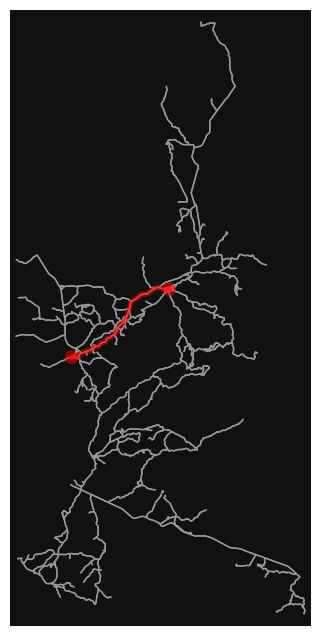

Sigue recto por Calle Morelos durante 87.8 metros
Sigue recto por Calle Morelos durante 66.1 metros
Sigue recto por Calle Morelos durante 90.8 metros
Sigue recto por Calle Morelos durante 90.1 metros
Sigue recto por Calle Morelos durante 254.9 metros
Gira a la izquierda por calle sin nombre durante 487.5 metros
Sigue recto por calle sin nombre durante 52.1 metros
Sigue recto por calle sin nombre durante 426.8 metros
Sigue recto por calle sin nombre durante 735.5 metros
Sigue recto por calle sin nombre durante 328.4 metros
Sigue recto por calle sin nombre durante 2029.4 metros
Sigue recto por calle sin nombre durante 586.4 metros
Sigue recto por calle sin nombre durante 158.6 metros
Sigue recto por calle sin nombre durante 999.1 metros
Sigue recto por calle sin nombre durante 406.9 metros
Sigue recto por calle sin nombre durante 594.5 metros
Sigue recto por calle sin nombre durante 64.6 metros
Sigue recto por calle sin nombre durante 693.0 metros
Gira a la derecha por calle sin nombre d

In [7]:
import json
import math
import networkx as nx
import osmnx as ox
from shapely.geometry import shape
from geopy.distance import geodesic

# Cargar el archivo GeoJSON
with open("VillaPesqueira.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Crear el polígono a partir del GeoJSON
polygon = shape(data["features"][0]["geometry"])

# Crear el grafo vial de la zona
G = ox.graph_from_polygon(polygon, network_type="drive")

# ---------------------------
# Seleccionar origen y destino (puedes cambiar estos valores)
# ---------------------------
origen_lat, origen_lon = 29.060924, -110.060873
destino_lat, destino_lon = 29.118444, -109.966675

# Obtener los nodos más cercanos
origen_nodo = ox.distance.nearest_nodes(G, origen_lon, origen_lat)
destino_nodo = ox.distance.nearest_nodes(G, destino_lon, destino_lat)

# Calcular la ruta más corta con A*
ruta_nodos = nx.astar_path(G, origen_nodo, destino_nodo, weight="length")

# Obtener las coordenadas (lat/lon) de la ruta
ruta_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in ruta_nodos]

# Mostrar la ruta (opcional)
print("Ruta:", ruta_coords)

# Mostrar en gráfico (opcional)
fig, ax = ox.plot_graph_route(G, ruta_nodos, route_linewidth=4, node_size=0)


# ----------------------------------------
# FUNCIONES PARA CALCULAR INSTRUCCIONES
# ----------------------------------------

def calcular_instrucciones_con_calles(G, ruta_nodos):
    instrucciones = []

    for i in range(1, len(ruta_nodos) - 1):
        u = ruta_nodos[i - 1]
        v = ruta_nodos[i]
        w = ruta_nodos[i + 1]

        coord_u = (G.nodes[u]['y'], G.nodes[u]['x'])
        coord_v = (G.nodes[v]['y'], G.nodes[v]['x'])
        coord_w = (G.nodes[w]['y'], G.nodes[w]['x'])

        # Calcular distancia
        dist = geodesic(coord_v, coord_w).meters

        # Calcular dirección
        def angulo(a, b):
            return math.degrees(math.atan2(b[1] - a[1], b[0] - a[0]))

        ang1 = angulo(coord_u, coord_v)
        ang2 = angulo(coord_v, coord_w)

        giro = (ang2 - ang1 + 360) % 360
        if giro < 30 or giro > 330:
            accion = "Sigue recto"
        elif giro < 180:
            accion = "Gira a la derecha"
        else:
            accion = "Gira a la izquierda"

        # Obtener nombre de la calle (puede haber varias)
        nombre_calle = None
        if G.has_edge(v, w):
            edge_data = G.get_edge_data(v, w)
        elif G.has_edge(w, v):
            edge_data = G.get_edge_data(w, v)
        else:
            edge_data = None

        if edge_data:
            edge = edge_data[0]  # Puede haber varias variantes (0 es la principal)
            nombre_calle = edge.get("name", "calle sin nombre")

        instrucciones.append({
            "accion": accion,
            "distancia_m": round(dist, 1),
            "desde": coord_v,
            "hacia": coord_w,
            "calle": nombre_calle
        })

    return instrucciones


# Obtener instrucciones
instrucciones = calcular_instrucciones_con_calles(G, ruta_nodos)

# Mostrar instrucciones
for paso in instrucciones:
    print(f"{paso['accion']} por {paso['calle']} durante {paso['distancia_m']} metros")


### Generar un Grafo del Mapa

In [1]:
# preparar_grafo.py
import json
import osmnx as ox
from shapely.geometry import shape

with open("VillaPesqueira.json", "r", encoding="utf-8") as f:
    data = json.load(f)

polygon = shape(data["features"][0]["geometry"])

# Cambiar simplify a False para conservar más nodos
G = ox.graph_from_polygon(polygon, network_type="drive", simplify=False)

print(f"✅ Grafo creado con {len(G.nodes)} nodos y {len(G.edges)} aristas")

ox.save_graphml(G, "grafo_villa_pesqueira.graphml")
print("✅ Grafo guardado como 'grafo_villa_pesqueira.graphml'")



c:\Users\malco\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


✅ Grafo creado con 17302 nodos y 34920 aristas
✅ Grafo guardado como 'grafo_villa_pesqueira.graphml'


# Mapa de prueba Usando Dijkstra

In [ ]:
import json
import math
import networkx as nx
import osmnx as ox
from geopy.distance import geodesic
import folium

# =========================
# FUNCIONES
# =========================

def cargar_grafo_desde_archivo(path="grafo_villa_pesqueira.graphml"):
    G = ox.load_graphml(path)
    G = G.to_undirected()
    return G


def construir_ruta_con_aproximacion(G, puntos_gps, max_dist_fuera_calle=10):
    nodos = []
    conexiones_verdes = []  # Lista de líneas verdes a dibujar
    ruta_nodos = []
    
    for i, punto in enumerate(puntos_gps):
        nodo_cercano = ox.distance.nearest_nodes(G, punto[1], punto[0])
        nodo_coord = (G.nodes[nodo_cercano]['y'], G.nodes[nodo_cercano]['x'])

        distancia = geodesic(punto, nodo_coord).meters
        nodos.append(nodo_cercano)

        # Si hay un nodo anterior, se calcula la ruta entre ambos nodos
        if i > 0:
            try:
                segmento = nx.dijkstra_path(G, nodos[i-1], nodos[i], weight="length")
                if i == 1:
                    ruta_nodos.extend(segmento)
                else:
                    ruta_nodos.extend(segmento[1:])
            except nx.NetworkXNoPath:
                print(f"No hay ruta entre {nodos[i-1]} y {nodos[i]}")

        # Si el punto GPS no está en la calle, guardar línea verde
        if distancia > max_dist_fuera_calle:
            conexiones_verdes.append((nodo_coord, punto))

    return ruta_nodos, conexiones_verdes

def calcular_instrucciones_con_calles(G, ruta_nodos):
    instrucciones = []
    distancia_total = 0

    def angulo(a, b):
        return math.degrees(math.atan2(b[1] - a[1], b[0] - a[0]))

    anterior = None
    for i in range(1, len(ruta_nodos) - 1):
        u, v, w = ruta_nodos[i - 1], ruta_nodos[i], ruta_nodos[i + 1]
        coord_u = (G.nodes[u]['y'], G.nodes[u]['x'])
        coord_v = (G.nodes[v]['y'], G.nodes[v]['x'])
        coord_w = (G.nodes[w]['y'], G.nodes[w]['x'])

        dist = geodesic(coord_v, coord_w).meters
        distancia_total += dist

        ang1 = angulo(coord_u, coord_v)
        ang2 = angulo(coord_v, coord_w)
        giro = (ang2 - ang1 + 360) % 360

        if giro < 30 or giro > 330:
            accion = "Sigue recto"
        elif giro < 180:
            accion = "Gira a la derecha"
        else:
            accion = "Gira a la izquierda"

        nombre_calle = "calle sin nombre"
        edge_data = G.get_edge_data(v, w) or G.get_edge_data(w, v)
        if edge_data:
            for key in edge_data:
                nombre_calle = edge_data[key].get("name", "calle sin nombre")
                if nombre_calle != "calle sin nombre":
                    break

        actual = {
            "accion": accion,
            "calle": nombre_calle,
            "desde": coord_v,
            "hacia": coord_w,
            "distancia_m": round(dist, 1)
        }

        if anterior and anterior["accion"] == actual["accion"] and anterior["calle"] == actual["calle"]:
            anterior["distancia_m"] += actual["distancia_m"]
            anterior["hacia"] = actual["hacia"]
        else:
            if anterior:
                instrucciones.append(anterior)
            anterior = actual

    if anterior:
        instrucciones.append(anterior)

    return instrucciones, round(distancia_total, 1)

def mostrar_ruta_en_mapa(puntos_gps, ruta_coords, conexiones_verdes, filename="mapa_ruta.html"):
    mapa = folium.Map(location=puntos_gps[0], zoom_start=17)

    # Ruta principal en azul
    folium.PolyLine(ruta_coords, color="blue", weight=5).add_to(mapa)

    # Dibujar conexiones verdes punteadas
    for nodo_coord, punto_coord in conexiones_verdes:
        folium.PolyLine([nodo_coord, punto_coord], color="green", weight=2, dash_array="5").add_to(mapa) # Línea punteada
        folium.Marker(punto_coord, icon=folium.Icon(color="red", icon="flag")).add_to(mapa) # Marcador rojo en puntos GPS
             

    mapa.save(filename)

# =========================
# ENTRADA
# =========================

puntos_gps = [
    (29.065639, -110.056448),  # Origen exacto
    (29.062039, -110.059091),
    (29.061682, -110.059015),
    (29.061276, -110.058870),
    (29.060744, -110.058027),   
    (29.060509, -110.057231),# Destino exacto
    (29.060145, -110.055659),
    (29.060063, -110.055008),
    (29.059944, -110.054195),
    (29.059486, -110.053973)
]

# =========================
# PROCESO
# =========================

G = cargar_grafo_desde_archivo("grafo_villa_pesqueira.graphml")
ruta_nodos, conexiones_verdes = construir_ruta_con_aproximacion(G, puntos_gps)
ruta_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in ruta_nodos]
instrucciones, distancia_total = calcular_instrucciones_con_calles(G, ruta_nodos)

resultado = {
    "puntos_gps": puntos_gps,
    "ruta": ruta_coords,
    "distancia_total_m": distancia_total,
    "distancia_total_km": round(distancia_total / 1000, 2),
    "instrucciones": instrucciones
}

with open("resultado_ruta.json", "w") as f:
    print("Generando archivo de Resultado...")
    json.dump(resultado, f, indent=2)
    print("Archivo Gnerado :)")

# Mostrar visualización
#mostrar_ruta_en_mapa(puntos_gps, ruta_coords, conexiones_verdes)


Generando archivo de Resultado...
Archivo Gnerado :)


# Prueba de mapa usando A*

In [7]:
import json
import math
import networkx as nx
import osmnx as ox
from geopy.distance import geodesic
import folium
from math import radians, cos, sin, asin, sqrt

# =========================
# |      FUNCIONES        |
# =========================

def heuristica_geodesica(u, v, G):
    """Calcula la distancia geodésica entre dos nodos del grafo G.

    Args:
        u (_type_): Esta es la instancia del nodo de origen en el grafo G.
        v (_type_): Esta es la instancia del nodo de destino en el grafo G.
        G (_type_): Esta es la instancia del grafo de OSMnx que contiene los nodos y sus coordenadas.

    Returns:
        _type_:   Devuelve la distancia geodésica entre los nodos u y v en metros.
    """
    lat1, lon1 = G.nodes[u]['y'], G.nodes[u]['x']
    lat2, lon2 = G.nodes[v]['y'], G.nodes[v]['x']
    return geodesic((lat1, lon1), (lat2, lon2)).meters

def cargar_grafo_desde_archivo(path="grafo_villa_pesqueira.graphml"):
    """Carga el grafo desde un archivo GraphML y lo convierte a no dirigido.

    Args:
        path (str, optional):  Ruta al archivo GraphML. Defaults to "grafo_villa_pesqueira.graphml".

    Returns:
        _type_:  Grafo de OSMnx cargado y convertido a no dirigido.
    """
    G = ox.load_graphml(path)
    G = G.to_undirected()
    return G


def construir_ruta_con_aproximacion(G, puntos_gps, max_dist_fuera_calle=10):
    """Calcula una ruta aproximada entre puntos GPS dados, utilizando el grafo de OSMnx.

    Args:
        G (_type_):  Grafo de OSMnx que representa la red vial.
        puntos_gps (_type_):  Lista de tuplas con coordenadas GPS (latitud, longitud).
        max_dist_fuera_calle (int, optional):   Distancia máxima permitida fuera de la calle para considerar un punto GPS. Defaults to 10.

    Returns:
        _type_:   Una tupla con dos elementos:
            - Una lista de nodos que componen la ruta aproximada.
            - Una lista de conexiones verdes (puntos GPS que están fuera de la calle).
    """
    nodos = []
    conexiones_verdes = []
    ruta_nodos = []

    for i, punto in enumerate(puntos_gps):
        nodo_cercano = ox.distance.nearest_nodes(G, punto[1], punto[0])
        nodo_coord = (G.nodes[nodo_cercano]['y'], G.nodes[nodo_cercano]['x'])
        distancia = geodesic(punto, nodo_coord).meters
        nodos.append(nodo_cercano)

        if i > 0:
            try:
                segmento = nx.astar_path(
                    G,
                    nodos[i - 1],
                    nodos[i],
                    heuristic=lambda u, v: heuristica_geodesica(u, v, G),
                    weight="length"
                )
                if i == 1:
                    ruta_nodos.extend(segmento)
                else:
                    ruta_nodos.extend(segmento[1:])
            except nx.NetworkXNoPath:
                print(f"No hay ruta entre {nodos[i-1]} y {nodos[i]}")

        if distancia > max_dist_fuera_calle:
            conexiones_verdes.append((nodo_coord, punto))

    return ruta_nodos, conexiones_verdes



def calcular_instrucciones_con_calles(G, ruta_nodos):
    """Calcula las instrucciones de la ruta dada una lista de nodos.

    Args:
        G (_type_): Grafo de OSMnx en formato no dirigido
        ruta_nodos (_type_):  Lista de nodos que componen la ruta

    Returns:
        _type_: Instrucciones de la ruta y distancia total
    """
    instrucciones = []
    distancia_total = 0

    def angulo(a, b):
        return math.degrees(math.atan2(b[1] - a[1], b[0] - a[0]))

    anterior = None
    for i in range(1, len(ruta_nodos) - 1):
        u, v, w = ruta_nodos[i - 1], ruta_nodos[i], ruta_nodos[i + 1]
        coord_u = (G.nodes[u]['y'], G.nodes[u]['x'])
        coord_v = (G.nodes[v]['y'], G.nodes[v]['x'])
        coord_w = (G.nodes[w]['y'], G.nodes[w]['x'])

        dist = geodesic(coord_v, coord_w).meters
        distancia_total += dist

        ang1 = angulo(coord_u, coord_v)
        ang2 = angulo(coord_v, coord_w)
        giro = (ang2 - ang1 + 360) % 360

        if giro < 30 or giro > 330:
            accion = "Sigue recto"
        elif giro < 180:
            accion = "Gira a la derecha"
        else:
            accion = "Gira a la izquierda"

        nombre_calle = "calle sin nombre"
        edge_data = G.get_edge_data(v, w) or G.get_edge_data(w, v)
        if edge_data:
            for key in edge_data:
                nombre_calle = edge_data[key].get("name", "calle sin nombre")
                if nombre_calle != "calle sin nombre":
                    break

        actual = {
            "accion": accion,
            "calle": nombre_calle,
            "desde": coord_v,
            "hacia": coord_w,
            "distancia_m": round(dist, 1)
        }

        if anterior and anterior["accion"] == actual["accion"] and anterior["calle"] == actual["calle"]:
            anterior["distancia_m"] += actual["distancia_m"]
            anterior["hacia"] = actual["hacia"]
        else:
            if anterior:
                instrucciones.append(anterior)
            anterior = actual

    if anterior:
        instrucciones.append(anterior)

    return instrucciones, round(distancia_total, 1)

def mostrar_ruta_en_mapa(puntos_gps, ruta_coords, conexiones_verdes, filename="mapa_ruta.html"):
    mapa = folium.Map(location=puntos_gps[0], zoom_start=17)

    # Ruta principal en azul
    folium.PolyLine(ruta_coords, color="blue", weight=5).add_to(mapa)

    # Dibujar conexiones verdes punteadas
    for nodo_coord, punto_coord in conexiones_verdes:
        folium.PolyLine([nodo_coord, punto_coord], color="green", weight=2, dash_array="5").add_to(mapa) # Línea punteada
        folium.Marker(punto_coord, icon=folium.Icon(color="red", icon="flag")).add_to(mapa) # Marcador rojo en puntos GPS
    
    mapa.save(filename)

# =========================
# |      ENTRADA          |
# =========================

puntos_gps = [
    (29.065639, -110.056448), # Origen exacto
    (29.062039, -110.059091),
    (29.061682, -110.059015),
    (29.061276, -110.058870),
    (29.060744, -110.058027),   
    (29.060509, -110.057231),
    (29.060145, -110.055659),
    (29.060063, -110.055008),
    (29.059944, -110.054195),
    (29.059486, -110.053973),
    (29.118091, -109.970340),
    (29.116921, -109.970124),
    (29.116096, -109.969460)# Destino exacto
]

# =========================
# |        PROCESO        |
# =========================

G = cargar_grafo_desde_archivo("grafo_villa_pesqueira.graphml") # Cargar el grafo previamente guardado
ruta_nodos, conexiones_verdes = construir_ruta_con_aproximacion(G, puntos_gps) # Construir la ruta con aproximación 
ruta_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in ruta_nodos] # Obtener las coordenadas de la ruta 
instrucciones, distancia_total = calcular_instrucciones_con_calles(G, ruta_nodos) # Calcular las instrucciones de la ruta

resultado = {
    "puntos_gps": puntos_gps,
    "ruta": ruta_coords,
    "distancia_total_m": distancia_total,
    "distancia_total_km": round(distancia_total / 1000, 2),
    "instrucciones": instrucciones
}

with open("resultado_ruta.json", "w") as f:
    print("Generando archivo de Resultado...")
    json.dump(resultado, f, indent=2)
    print("Archivo Gnerado :)")

# Mostrar visualización
#mostrar_ruta_en_mapa(puntos_gps, ruta_coords, conexiones_verdes)


Generando archivo de Resultado...
Archivo Gnerado :)


# Se muestra La visualizacion de un mapa con una ruta desde un archivo JSON

In [8]:
import json
import folium
from geopy.distance import geodesic

# Cargar datos del JSON
with open("resultado_ruta.json", "r", encoding="utf-8") as f:
    datos = json.load(f)

puntos_gps = datos["puntos_gps"]
ruta_coords = datos["ruta"]
instrucciones = datos["instrucciones"]

# Crear el mapa
mapa = folium.Map(location=puntos_gps[0], zoom_start=16)

# Dibujar la ruta principal (azul)
folium.PolyLine(ruta_coords, color="blue", weight=5, opacity=0.8).add_to(mapa)

# Dibujar conexiones punteadas si el punto GPS no está exactamente sobre la ruta
for punto in puntos_gps:
    # Buscar el punto más cercano en la ruta
    punto_coord = tuple(punto)
    mas_cercano = min(ruta_coords, key=lambda r: geodesic(punto_coord, tuple(r)).meters)
    distancia = geodesic(punto_coord, mas_cercano).meters

    # Dibujar conexión solo si hay más de 5 metros de diferencia
    if distancia > 5:
        folium.PolyLine([punto_coord, mas_cercano], color="green", weight=2, dash_array="5").add_to(mapa)

    # Agregar marcador rojo para el punto original
    folium.Marker(punto_coord, icon=folium.Icon(color="red", icon="flag")).add_to(mapa)

# Agregar instrucciones como card flotante
from branca.element import MacroElement
from jinja2 import Template

card_html = "<div id='instruction-card' style='position: fixed; top: 10px; right: 10px; width: 320px; max-height: 400px; overflow-y: auto; background: white; border: 2px solid gray; padding: 10px; z-index: 1000;'>"
card_html += "<h4>Instrucciones</h4><ol style='padding-left: 20px;'>"

for instr in instrucciones:
    texto = f"{instr['accion']} en {instr['calle']} ({round(instr['distancia_m'],1)} m)"
    card_html += f"<li>{texto}</li>"

card_html += "</ol></div>"

# Componente flotante
class HtmlElement(MacroElement):
    def __init__(self, html):
        super().__init__()
        self._template = Template(f"""
            {{% macro script(this, kwargs) %}}
            var div = L.DomUtil.create('div');
            div.innerHTML = `{html}`;
            document.body.appendChild(div);
            {{% endmacro %}}
        """)

html_element = HtmlElement(card_html)
mapa.get_root().add_child(html_element)

# Guardar el mapa
mapa.save("../docs/visualizacion_ruta.html")
